# **Titanic Survival Prediction:** Model Evaluation & Tuning

---
This notebook focus on **evaluation beyond accuracy** and systematic model tuning using `GridSearchCV`.

---

## Objectives
- Calculate Precision, Recall and F1-score
- Understand why accuracy can be misleading
- Tune **two Logistic Regression hyperparameters**
- Compare the original and tuned models



## 1. Import Libraries

We import the tools needed for preprocessing, Logistic Regression, evaluation and hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the Titanic Dataset

We continue with the same `train.csv` dataset used in the previous Titanic project.

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('train.csv')
df.head()

Saving train.csv to train.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 📌 Output Interpretation
The preview confirms that the dataset contains passenger characteristics and the `Survived` target. We will use these features to predict survival.

## 3. Select Features and Target

We use the main features from the previous Logistic Regression workflow. Identifier/text-heavy columns such as `PassengerId`, `Name`, and `Ticket` are excluded.

In [3]:
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']

X = df[features]
y = df['Survived']

print("Dataset shape:", X.shape)
print("Target:", y.name)

Dataset shape: (891, 7)
Target: Survived


### 📌 Output Interpretation
`X` contains the predictor variables and `y` contains the survival outcome. The model will learn the relationship between these passenger characteristics and survival.

## 4. Train-Test Split

We reserve 20% of the data for final testing. `stratify=y` keeps the class proportions similar in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 712
Testing records: 179


### 📌 Output Interpretation
The training set is used to learn the model, while the test set represents unseen passengers used for final evaluation.

## 5. Check Class Distribution

Before evaluating a classifier, we should understand the balance between the two target classes.

In [5]:
class_counts = y.value_counts().sort_index()
print(class_counts)
print("\nClass percentages:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


### 📌 Why Accuracy Alone Can Mislead

Accuracy is the percentage of all predictions that are correct. If one class is much larger than the other, a model can achieve high accuracy simply by predicting the majority class most of the time.

For example, if 90% of observations belong to one class, always predicting that class gives 90% accuracy but completely misses the minority class. Precision, Recall and F1-score therefore provide a more complete view of performance.

## 6. Preprocessing Pipeline

Missing numerical values are replaced with the median. Missing categorical values use the most frequent category. Categorical features are then one-hot encoded.

In [6]:
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### 📌 Output Interpretation
The pipeline prepares both numerical and categorical data automatically. Keeping preprocessing inside the pipeline also helps prevent data leakage.

## 7. Original Logistic Regression Model

This is our baseline model. Its results will be used as the **before-tuning** benchmark.

In [7]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

### 📌 Output Interpretation
The baseline model has learned from the training data and produced predictions for the unseen test set.

## 8. Evaluate the Original Model

We calculate Accuracy, Precision, Recall and F1-score. The classification report gives these metrics for both classes.

In [8]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline Accuracy :", round(baseline_accuracy, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall   :", round(baseline_recall, 4))
print("Baseline F1-score :", round(baseline_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline Accuracy : 0.8045
Baseline Precision: 0.7931
Baseline Recall   : 0.6667
Baseline F1-score : 0.7244

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### 📌 Output Interpretation
Precision measures how reliable positive predictions are. Recall measures how many actual survivors were correctly identified. F1-score balances Precision and Recall, so it is useful when we want to consider both.

## 9. Tune the Model with GridSearchCV

Instead of guessing settings, GridSearchCV tests combinations systematically. We tune two hyperparameters: **`C`** and **`class_weight`**. F1-score is used as the search objective.

In [9]:
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1-score:",
      round(grid_search.best_score_, 4))

Best Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced'}

Best Cross-Validation F1-score: 0.7344


### 📌 Output Interpretation
GridSearchCV evaluates the parameter combinations using 5-fold cross-validation. The displayed combination produced the best average F1-score on the training folds.

## 10. Evaluate the Tuned Model

We now test the best model on the same unseen test set used for the baseline.

In [10]:
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, zero_division=0)
tuned_recall = recall_score(y_test, tuned_pred, zero_division=0)
tuned_f1 = f1_score(y_test, tuned_pred, zero_division=0)

print("Tuned Accuracy :", round(tuned_accuracy, 4))
print("Tuned Precision:", round(tuned_precision, 4))
print("Tuned Recall   :", round(tuned_recall, 4))
print("Tuned F1-score :", round(tuned_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred, zero_division=0))

Tuned Accuracy : 0.7933
Tuned Precision: 0.7162
Tuned Recall   : 0.7681
Tuned F1-score : 0.7413

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       110
           1       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



### 📌 Output Interpretation
The tuned model is evaluated with exactly the same metrics as the original model. This makes the before/after comparison fair and easy to understand.

## 11. Before vs After Comparison

In [11]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Original Model': [
        baseline_accuracy, baseline_precision,
        baseline_recall, baseline_f1
    ],
    'Tuned Model': [
        tuned_accuracy, tuned_precision,
        tuned_recall, tuned_f1
    ]
})

comparison['Change'] = (
    comparison['Tuned Model'] - comparison['Original Model']
)

comparison.round(4)

,Metric,Original Model,Tuned Model,Change
0,Accuracy,0.8045,0.7933,-0.0112
1,Precision,0.7931,0.7162,-0.0769
2,Recall,0.6667,0.7681,0.1014
3,F1-score,0.7244,0.7413,0.0168


### 📌 Output Interpretation

The `Change` column shows the effect of tuning. A positive number means the tuned model improved that metric, while a negative number means it decreased.

The goal is not simply to increase accuracy; we also want to understand how Precision, Recall and F1-score changed.

## 12. Confusion Matrix — Tuned Model

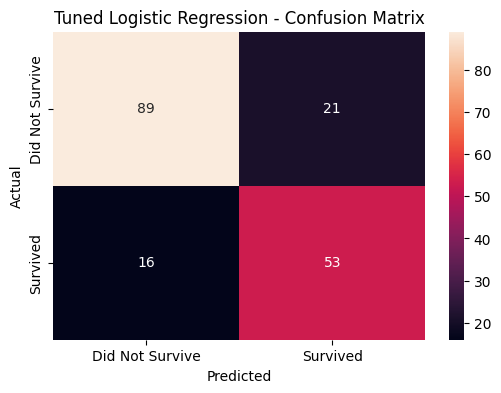

In [12]:
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Logistic Regression - Confusion Matrix')
plt.show()

### 📌 Output Interpretation
The confusion matrix shows correct and incorrect predictions for each class. It helps us see the types of errors that accuracy alone cannot explain.

---

# **Key Takeaways**

- Accuracy should not be the only metric used to evaluate a classification model.
- Precision, Recall and F1-score provide more detailed information about model performance.
- `GridSearchCV` provides a systematic way to tune hyperparameters.
- This task tuned two Logistic Regression parameters: `C` and `class_weight`.
- A before/after comparison makes it clear whether tuning actually improved the model.


---

# ✅ **General Conclusion**

In this analysis, the Titanic Logistic Regression model was evaluated beyond accuracy using Precision, Recall and F1-score. The model was then improved systematically with GridSearchCV by tuning two hyperparameters.

The before-and-after table shows how the tuned model compares with the original model. The main lesson is that **a good machine learning model is not simply the model with the highest accuracy; we should choose evaluation metrics that help us understand the types of predictions and errors the model makes.**

---